# TensorFlow

Sequential API tutorial on the MNIST dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.16.2'

In [3]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 32

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

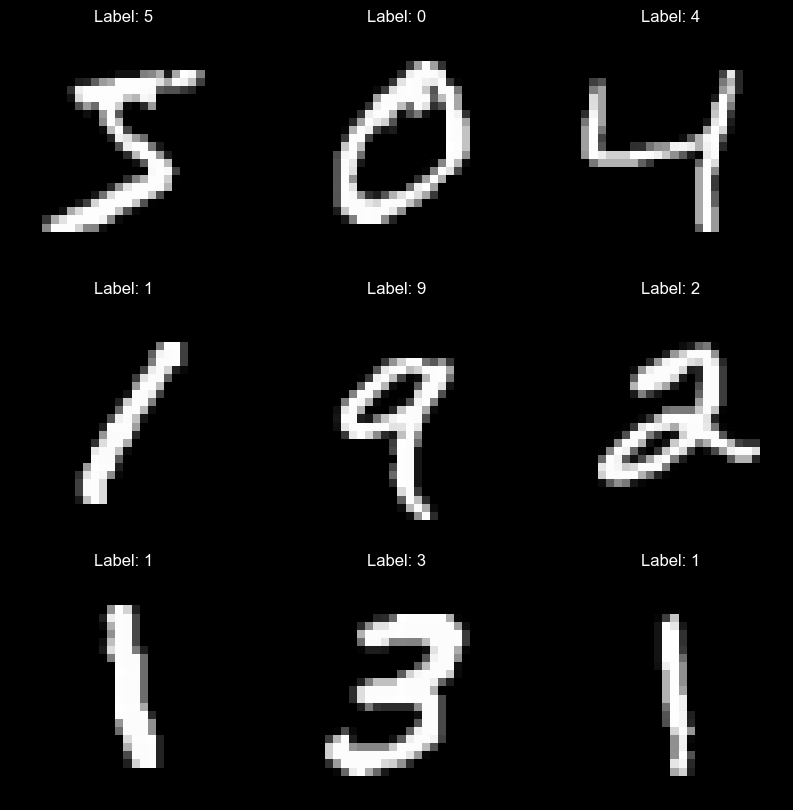

In [6]:
# display examples from the training set 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        axes[i, j].imshow(x_train[i * 3 + j], cmap='gray')
        axes[i, j].set_title(f'Label: {y_train[i * 3 + j]}')
        axes[i, j].axis('off')
plt.show()

In [7]:
# create a model using the Sequential API
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28), name="input"),
    keras.layers.Flatten(name="flatten"),
    keras.layers.Dense(64, activation='relu', name="hidden-1"),
    keras.layers.Dense(10, activation='softmax', name="output")
])

2026-03-16 09:45:10.776007: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-16 09:45:10.776031: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-16 09:45:10.776036: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-16 09:45:10.776048: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-16 09:45:10.776055: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [11]:
# train the model
history = model.fit(x_train, y_train,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25


2026-03-16 09:45:11.468354: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1594/1594 - 10s - 6ms/step - accuracy: 0.8249 - loss: 15.7955 - val_accuracy: 0.8664 - val_loss: 13.3678
Epoch 2/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8610 - loss: 14.4499 - val_accuracy: 0.8699 - val_loss: 13.8541
Epoch 3/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8667 - loss: 15.8234 - val_accuracy: 0.8840 - val_loss: 14.4662
Epoch 4/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8701 - loss: 17.3747 - val_accuracy: 0.8656 - val_loss: 17.1144


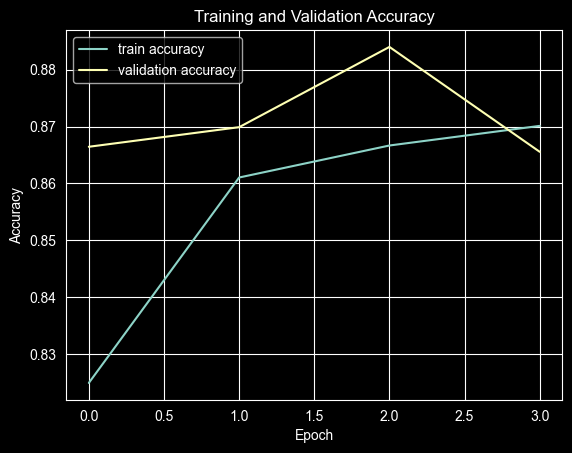

In [12]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [13]:
# test the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.8498 - loss: 15.5389
Test accuracy: 0.8498


In [14]:
# do the same thing but with a normalized dataset
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [15]:
# retrain the model with normalized data
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8265 - loss: 0.9359 - val_accuracy: 0.8760 - val_loss: 0.7081
Epoch 2/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8716 - loss: 0.6099 - val_accuracy: 0.8962 - val_loss: 0.4740
Epoch 3/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8895 - loss: 0.4510 - val_accuracy: 0.9090 - val_loss: 0.3631
Epoch 4/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9013 - loss: 0.3691 - val_accuracy: 0.9169 - val_loss: 0.3087
Epoch 5/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9100 - loss: 0.3255 - val_accuracy: 0.9193 - val_loss: 0.2858
Epoch 6/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9144 - loss: 0.3028 - val_accuracy: 0.9236 - val_loss: 0.2680
Epoch 7/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9172 - loss: 0.2933 - val_accuracy: 0.9233 - val_loss: 0.2686
Epoch 8/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9169 - loss: 0.2953 - val_accuracy: 0.9229 - val_loss: 0.2731
Epoch 9/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9160 - loss: 0.2996 - val_accuracy: 0.9213 - 

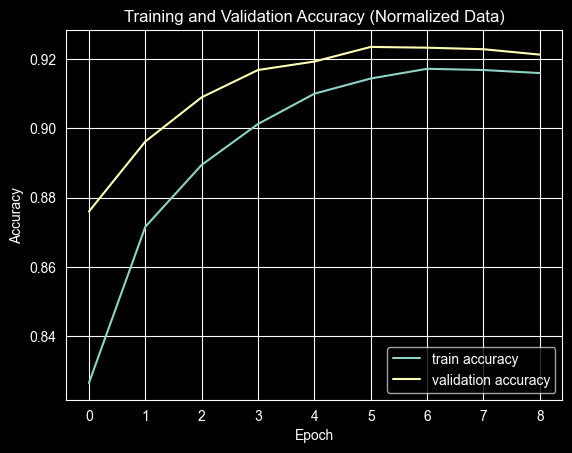

In [16]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy (Normalized Data)')
plt.show()

In [17]:
# test the model with normalized data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy (normalized data): {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.9185 - loss: 0.2817
Test accuracy (normalized data): 0.9185


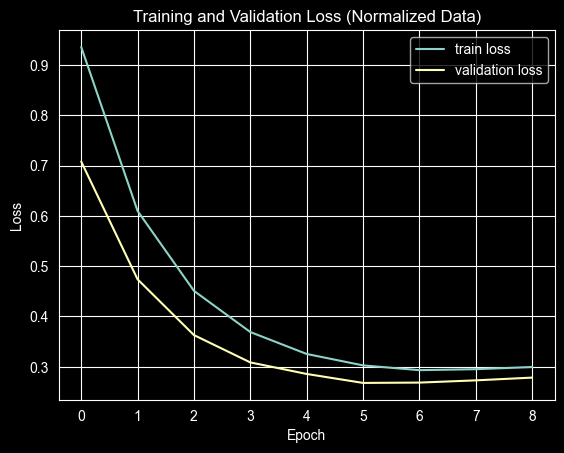

In [18]:
# plot the training and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Normalized Data)')
plt.show()

In [52]:
# save the model
model.save("mnist_dense_model.keras")

Let's see how a deeper model performs on the same dataset.

In [39]:
model_2 = keras.Sequential([
    keras.layers.Input(shape=(28, 28), name="input"),
    keras.layers.Flatten(name="flatten"),
    keras.layers.Dense(32, activation='relu', name="hidden-2"),
    keras.layers.Dense(10, activation='softmax', name="output")
])

In [40]:
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-2 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# compile the model
model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [42]:
# callbacks
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
save_model = keras.callbacks.ModelCheckpoint('dense_2.keras', save_best_only=True)
learning_rate_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=2, verbose=1)

In [44]:
# fit the model
history = model_2.fit(x_train, y_train,
                      epochs=NUM_EPOCHS,
                      verbose=2,
                      callbacks=[early_stopping],
                      validation_data=(x_test, y_test),
)

Epoch 1/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9158 - loss: 0.2989 - val_accuracy: 0.9203 - val_loss: 0.2822
Epoch 2/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9184 - loss: 0.2900 - val_accuracy: 0.9202 - val_loss: 0.2842
Epoch 3/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9212 - loss: 0.2877 - val_accuracy: 0.9158 - val_loss: 0.2970
Epoch 4/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9204 - loss: 0.2858 - val_accuracy: 0.9213 - val_loss: 0.2864
Epoch 5/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9197 - loss: 0.2855 - val_accuracy: 0.9169 - val_loss: 0.3008
Epoch 6/25
1875/1875 - 9s - 5ms/step - accuracy: 0.9201 - loss: 0.2863 - val_accuracy: 0.9161 - val_loss: 0.2951


In [45]:
# test the model
model_2.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9203 - loss: 0.2822


[0.2822175920009613, 0.9203000068664551]